# Supernovas

Emmanuel Juda Rodriguez Nachez

Programa que usa los datos provistos en clase para calcular parametros cosmologicos usando supernovas

In [8]:
import numpy as np
from astropy.cosmology import LambdaCDM
from astropy.cosmology import FlatLambdaCDM

import matplotlib.pyplot as plt
from astropy import units as u
import pandas as pd
import corner
import emcee

In [36]:
#Definimos likelihoods de los dos casos (por el momento), con flatLCDM y LCDM
def log_likelihoodFlat(theta, z, mB, c, xi, C_inv):
    alpha, beta, H0, Om = theta
    db = np.zeros(len(z))
    dh = np.zeros(len(z))

    cosmo = FlatLambdaCDM(H0=H0, Om0=Om)
    
    model = 5*np.log10(cosmo.luminosity_distance(z).to(u.pc).value/10)
    data = mB + alpha*xi - beta*c + 19.252 - db + dh

    dD = data - model

    return -0.5 * (dD @ C_inv @ dD)

def log_likelihoodnoFlat(theta, z, mB, c, xi, C_inv):
    alpha, beta, H0, Om, Ol = theta
    db = np.zeros(len(z))
    dh = np.zeros(len(z))

    cosmo = LambdaCDM(H0=H0, Om0=Om, Ode0=Ol)
    
    model = 5*np.log10(cosmo.luminosity_distance(z).to(u.pc).value/10)
    data = mB + alpha*xi - beta*c + 19.252 - db + dh

    dD = data - model

    return -0.5 * (dD @ C_inv @ dD)

def log_priorFlat(theta, upper, lower):
    alpha, beta, M, Om = theta
    
    if lower[0] < alpha < upper[0] and lower[1] < beta < upper[1] and lower[2] < M < upper[2] and lower[3] < Om < upper[3]:
        return 0.0
    return -np.inf

def log_priornoFlat(theta, upper, lower):
    alpha, beta, M, Om, Ol = theta
    
    if lower[0] < alpha < upper[0] and lower[1] < beta < upper[1] and lower[2] < M < upper[2] and lower[3] < Om < upper[3]  and lower[4] < Ol < upper[4]:
        return 0.0
    return -np.inf

def log_probabilityFlat(theta, z, mB, c, xi, C_inv, upper, lower):
    lp = log_priorFlat(theta, upper, lower)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihoodFlat(theta, z, mB, c, xi, C_inv)
    
def log_probabilitynoFlat(theta, z, mB, c, xi, C_inv, upper, lower):
    lp = log_priornoFlat(theta, upper, lower)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihoodnoFlat(theta, z, mB, c, xi, C_inv)

In [30]:
#Cargamos los datos y matriz de covarianza estadistica
data = pd.read_csv('Pantheon+SH0ES.dat', sep=' ')
err = np.genfromtxt("Pantheon+SH0ES_STATONLY.cov", delimiter=" ", usemask=False, skip_header=1)

In [41]:
#Dividimos los datos en arrays de solo las cosas que necesitamos
z = np.array(data['zHD'].array)
mB = np.array(data['mB'].array)
c = np.array(data['c'].array)
x1 = np.array(data['x1'].array)

#Arreglamos la matriz de covarianza que venia originalmente en un array de 1701x1701 componentes a una matriz cuadrada

C_stat = np.reshape(err, (1701,1701))
#Calculamos la inversa de la matriz de covarianza
C_inv = np.linalg.inv(C_stat)

#definimos parametros de la inferencia, nombres de variables, limites y puntos de partida
labels = ['alpha', 'beta', 'H0', 'Om']

upper = [20, 20, 90, 0.7]
lower = [0.0,0.0, 50,0.01]

initial_theta = np.array([0.15, 3.0, 70, 0.3])
sigma = np.array([0.01, 0.01, 0.01, 0.001])
initial_spread = np.array([0.01, 0.01, 1, 0.05])

n_walkers = 50
n_steps = 1000
theta = np.array([np.random.normal(initial_theta, initial_spread) for _ in range(n_walkers)])

In [42]:
#Hacemos la inferencia
samplerFlat = emcee.EnsembleSampler(
    n_walkers, len(initial_spread), log_probabilityFlat, args=(z, mB, c, x1, C_inv, upper, lower)
)
samplerFlat.run_mcmc(theta, n_steps, progress=True);

100%|███████████████████████████████████████| 1000/1000 [21:31<00:00,  1.29s/it]


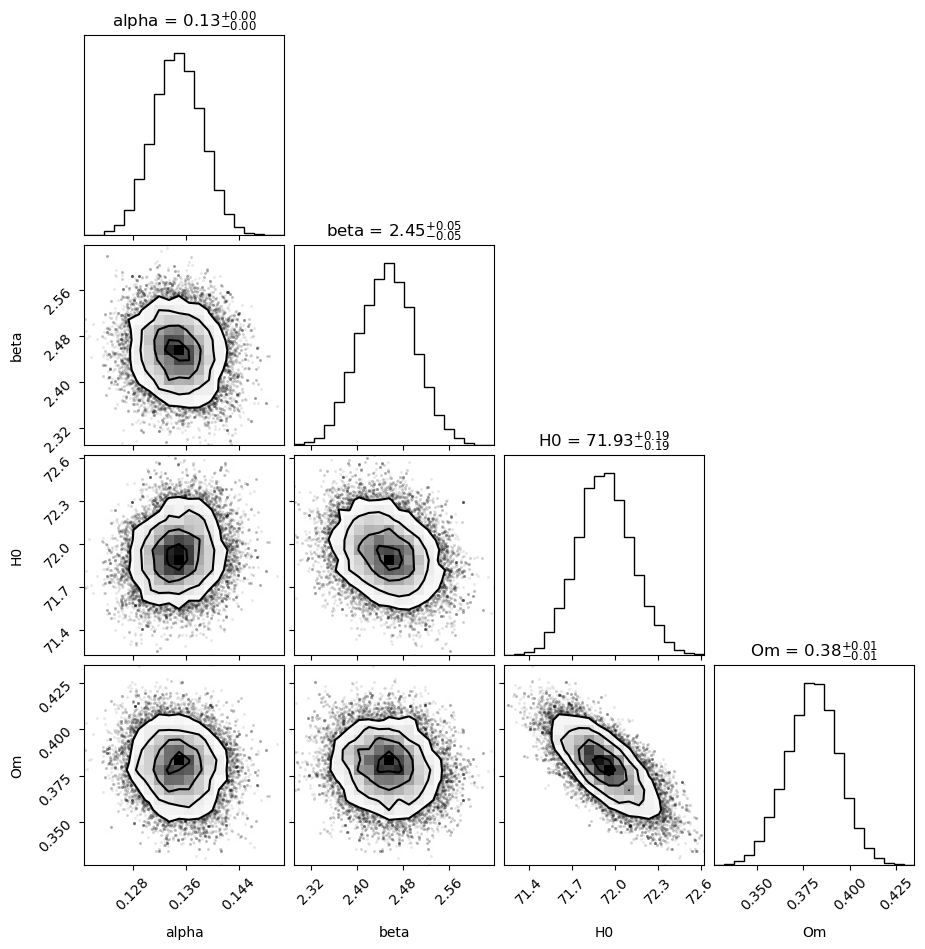

In [43]:
#Desechamos cada los primeros 500 pasos y graficamos
flat_samplesFlat = samplerFlat.get_chain(discard=300, thin=1, flat=True)
fig = corner.corner(
    flat_samplesFlat, labels=labels, show_titles=True);

In [44]:
#Mismo procedimiento pero para LCDM

labels = ['alpha', 'beta', 'H0', 'Om', 'Ol']

upper = [2, 20, 90, 0.99, 0.99]
lower = [0.0,0.0,50,0.01,0.01]

initial_theta = np.array([0.15, 3.0, 70, 0.3, 0.7])
sigma = np.array([0.01, 0.01, 0.01, 0.001,0.001])
initial_spread = np.array([0.01, 0.01, 1, 0.05, 0.05])

n_walkers = 50
n_steps = 1000
theta = np.array([np.random.normal(initial_theta, initial_spread) for _ in range(n_walkers)])

In [45]:
samplernoFlat = emcee.EnsembleSampler(
    n_walkers, len(initial_spread), log_probabilitynoFlat, args=(z, mB, c, x1, C_inv, upper, lower)
)
samplernoFlat.run_mcmc(theta, n_steps, progress=True);

100%|███████████████████████████████████████| 1000/1000 [23:20<00:00,  1.40s/it]


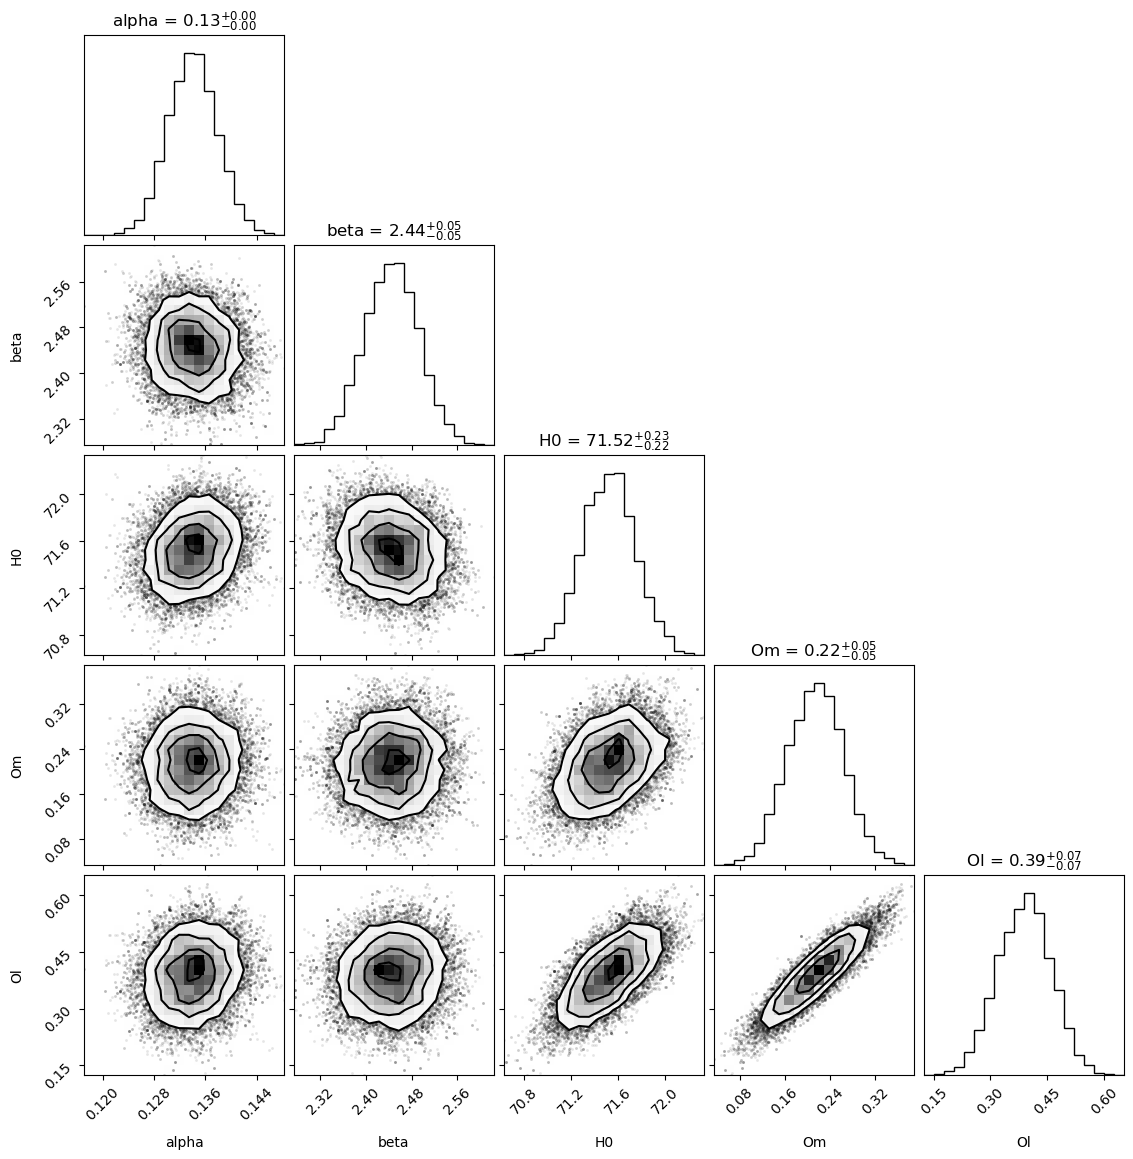

In [46]:
#Desechamos cada los primeros 500 pasos y graficamos
flat_samplesnoFlat = samplernoFlat.get_chain(discard=300, thin=1, flat=True)
fig = corner.corner(
    flat_samplesnoFlat, labels=labels, show_titles=True);